In [2]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import random

In [2]:
!pip install opencv-python

/usr/bin/pip:6: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import load_entry_point
     |████████████████████████████████| 72.9 MB 232 kB/s eta 0:00:01


In [3]:
!pip install wandb
import wandb
wandb.login()

/usr/bin/pip:6: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import load_entry_point


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/hardik/.netrc.
wandb: Currently logged in as: saniav2711 (ishaya-2716) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

Moving the folders ending with DPM into a new folder (on which the model will trai)

In [10]:
import os
import shutil

main_folder = "MOT17/train"
destination_folder = "train-main"

os.makedirs(destination_folder, exist_ok=True)

for item in os.listdir(main_folder):
    item_path = os.path.join(main_folder, item)
    if os.path.isdir(item_path) and item.endswith("DPM"):
        dest_path = os.path.join(destination_folder, item)

        print(f"Moving: {item_path} → {dest_path}")
        shutil.move(item_path, dest_path)

print("Transfer completed")

Transfer completed


In [11]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [12]:
class MOT17Dataset(Dataset):
    def __init__(self, mot_root, img_size=640, detector="DPM"):
        self.img_size = img_size
        self.samples = []
        mot_root = Path(mot_root)
        sequences = sorted([
            d for d in mot_root.iterdir()
            if d.is_dir() and d.name.endswith(f"-{detector}")
        ])
        print(f"Found {len(sequences)} sequences")
        for seq_dir in sequences:
            gt_path = seq_dir / "gt" / "gt.txt"
            img_dir = seq_dir / "img1"
            if not gt_path.exists():
                continue
            frame_boxes = {}
            with open(gt_path) as f:
                for line in f:
                    parts = line.strip().split(",")
                    if len(parts) < 8:
                        continue
                    frame_id = int(parts[0])
                    conf     = int(parts[6])
                    cls      = int(parts[7])
                    if conf != 1 or cls != 1:
                        continue
                    x, y, w, h = float(parts[2]), float(parts[3]), float(parts[4]), float(parts[5])
                    x1, y1 = max(0, x), max(0, y)
                    x2, y2 = x1 + w, y1 + h
                    if w <= 0 or h <= 0:
                        continue
                    frame_boxes.setdefault(frame_id, []).append([x1, y1, x2, y2])
            for frame_id, boxes in frame_boxes.items():
                img_path = img_dir / f"{frame_id:06d}.jpg"
                if img_path.exists():
                    self.samples.append((str(img_path), boxes))
        print(f"Total samples: {len(self.samples)}")
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        img_path, boxes = self.samples[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        img = cv2.resize(img, (self.img_size, self.img_size))
        scale_x = self.img_size / w
        scale_y = self.img_size / h
        scaled_boxes = []
        for (x1, y1, x2, y2) in boxes:
            x1 = min(x1 * scale_x, self.img_size - 1)
            y1 = min(y1 * scale_y, self.img_size - 1)
            x2 = min(x2 * scale_x, self.img_size - 1)
            y2 = min(y2 * scale_y, self.img_size - 1)
            if x2 > x1 and y2 > y1:
                scaled_boxes.append([x1, y1, x2, y2])
        img = torch.tensor(img).permute(2, 0, 1).float() / 255.0
        if len(scaled_boxes) == 0:
            boxes_tensor  = torch.zeros((0, 4), dtype=torch.float32)
            labels_tensor = torch.zeros((0,),   dtype=torch.int64)
        else:
            boxes_tensor  = torch.tensor(scaled_boxes, dtype=torch.float32)
            labels_tensor = torch.ones(len(scaled_boxes), dtype=torch.int64)  # 1 = person
        target = {
            "boxes":  boxes_tensor,
            "labels": labels_tensor,
        }
        return img, target

Found 7 sequences
Total samples: 5316
Image shape: torch.Size([3, 640, 640])
Boxes: tensor([[446.0000, 247.7037, 501.6667, 472.2963],
        [195.3333, 264.8889, 223.6667, 420.7408],
        [472.0000, 255.4074, 533.3333, 454.5185]])
Labels: tensor([1, 1, 1])
x2>x1: tensor(True)
y2>y1: tensor(True)


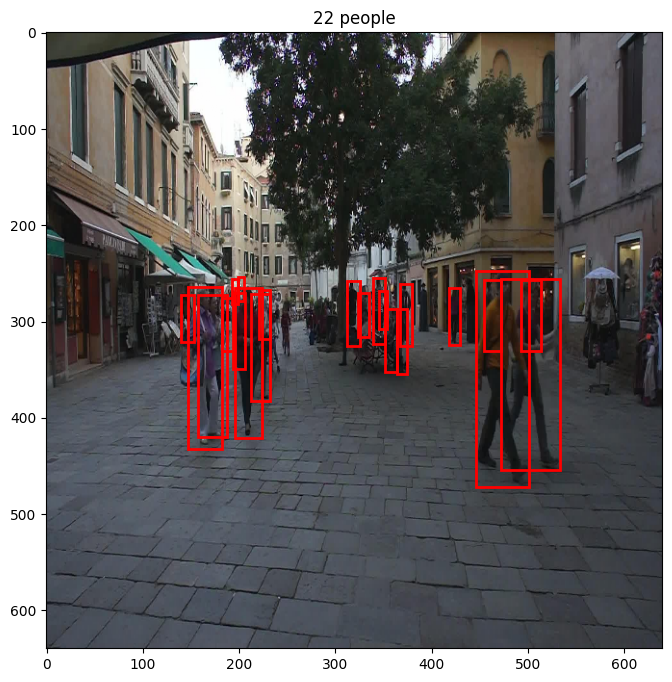

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

MOT_ROOT = "train-main"

dataset = MOT17Dataset(MOT_ROOT, img_size=640)
img, target = dataset[0]
print("Image shape:", img.shape)
print("Boxes:", target['boxes'][:3])
print("Labels:", target['labels'][:3])
print("x2>x1:", (target['boxes'][:,2] > target['boxes'][:,0]).all())
print("y2>y1:", (target['boxes'][:,3] > target['boxes'][:,1]).all())

fig, ax = plt.subplots(1, figsize=(8,8))
ax.imshow(img.permute(1,2,0))
for box in target['boxes']:
    x1,y1,x2,y2 = box
    rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                               linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
plt.title(f"{len(target['boxes'])} people")
plt.show()

In [11]:
!pip install matplotlib

/usr/bin/pip:6: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import load_entry_point
     |████████████████████████████████| 9.2 MB 5.5 MB/s eta 0:00:01
     |████████████████████████████████| 301 kB 5.9 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 6.1 MB/s eta 0:00:01
     |████████████████████████████████| 1.2 MB 8.8 MB/s eta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [14]:
from torch.utils.data import random_split, DataLoader
def collate_fn(batch):
    return tuple(zip(*batch))
dataset = MOT17Dataset("train-main", img_size=640)

total      = len(dataset)
train_size = int(0.8 * total)
val_size   = total - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(dataset, [train_size, val_size],
                                           generator=generator)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,
                          num_workers=2, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False,
                          num_workers=2, collate_fn=collate_fn)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Found 7 sequences
Total samples: 5316
Train: 4252 | Val: 1064


In [15]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

class FastRCNNPredictorWithDropout(nn.Module):
    def __init__(self, in_channels, num_classes, dropout_p=0.2):  # 0.3 → 0.2
        super().__init__()
        self.dropout   = nn.Dropout(p=dropout_p)
        self.cls_score = nn.Linear(in_channels, num_classes)
        self.bbox_pred = nn.Linear(in_channels, num_classes * 4)

    def forward(self, x):
        x           = self.dropout(x)
        scores      = self.cls_score(x)
        bbox_deltas = self.bbox_pred(x)
        return scores, bbox_deltas

original_fastrcnn_loss = torchvision.models.detection.roi_heads.fastrcnn_loss

def fastrcnn_loss_with_smoothing(class_logits, box_regression, labels, regression_targets):
    num_classes = class_logits.shape[1]
    labels_cat  = torch.cat(labels, dim=0)

    # smoothed classification loss
    smoothed = torch.full_like(class_logits, 0.1 / num_classes)
    smoothed.scatter_(1, labels_cat.unsqueeze(1), 1.0 - 0.1 + 0.1 / num_classes)
    cls_loss = (
        F.cross_entropy(class_logits, labels_cat) * 0.9 +
        (-smoothed * F.log_softmax(class_logits, dim=1)).sum(dim=1).mean() * 0.1
    )


    _, box_loss = original_fastrcnn_loss(
        class_logits, box_regression, labels, regression_targets
    )

    return cls_loss, box_loss

torchvision.models.detection.roi_heads.fastrcnn_loss = fastrcnn_loss_with_smoothing
print("Label smoothing patch applied")

model = fasterrcnn_resnet50_fpn(pretrained=True)

num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictorWithDropout(
    in_features,
    num_classes,
    dropout_p=0.2
)

for param in model.backbone.parameters():
    param.requires_grad = False

model.to(device)
print("Model ready")

Using: cuda
Label smoothing patch applied


/home/hardik/.local/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/hardik/.local/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model ready


In [16]:
!pip install torchvision

/usr/bin/pip:6: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import load_entry_point
     |████████████████████████████████| 7.0 MB 4.7 MB/s eta 0:00:01


In [17]:
import wandb
from tqdm import tqdm

wandb.init(project="mot17-detection", name="exp5-dropout0.2-lr2e4-warmup-labelsmooth-50ep")

num_epochs    = 50
warmup_epochs = 5
best_val_loss = float('inf')

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-4,
    weight_decay=0.05
)

def lr_lambda(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    return 1.0

warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=num_epochs - warmup_epochs, eta_min=1e-6
)

wandb.config.update({
    "epochs":          num_epochs,
    "warmup_epochs":   warmup_epochs,
    "lr":              2e-4,
    "weight_decay":    0.05,
    "dropout":         0.2,
    "label_smoothing": 0.1,
    "scheduler":       "warmup+cosine",
    "optimizer":       "AdamW",
    "backbone_frozen": True,
})

for epoch in range(num_epochs):
    print(f"\n===== Epoch {epoch+1}/{num_epochs} =====")

    model.train()
    epoch_loss = 0

    for imgs, targets in tqdm(train_loader, desc="Train"):
        imgs    = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        losses    = sum(loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += losses.item()

    avg_train = epoch_loss / len(train_loader)
    print(f"Train Loss: {avg_train:.4f}")

    model.train()
    model.roi_heads.box_predictor.dropout.eval()

    val_loss      = 0
    val_loss_dict = {"loss_classifier": 0, "loss_box_reg": 0,
                     "loss_objectness": 0, "loss_rpn_box_reg": 0}

    with torch.no_grad():
        for imgs, targets in tqdm(val_loader, desc="Val"):
            imgs    = [img.to(device) for img in imgs]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(imgs, targets)

            for k, v in loss_dict.items():
                if k in val_loss_dict:
                    val_loss_dict[k] += v.item()

            val_loss += sum(loss_dict.values()).item()

    model.roi_heads.box_predictor.dropout.train()

    avg_val = val_loss / len(val_loader)
    print(f"Val Loss:   {avg_val:.4f}")

    current_lr = optimizer.param_groups[0]['lr']
    if epoch < warmup_epochs:
        warmup_scheduler.step()
    else:
        cosine_scheduler.step()

    wandb.log({
        "epoch":                epoch + 1,
        "train_loss":           avg_train,
        "val_loss":             avg_val,
        "train_val_gap":        avg_train - avg_val,
        "lr":                   current_lr,
        "val_loss_classifier":  val_loss_dict["loss_classifier"]  / len(val_loader),
        "val_loss_box_reg":     val_loss_dict["loss_box_reg"]     / len(val_loader),
        "val_loss_objectness":  val_loss_dict["loss_objectness"]  / len(val_loader),
        "val_loss_rpn_box_reg": val_loss_dict["loss_rpn_box_reg"] / len(val_loader),
    })

    # ── Save Best Model ────────────────────────────────────────────
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(
            model.state_dict(),
            "model_weights/best_model_exp5.pth"
        )
        print(f"  Saved best model (val_loss: {avg_val:.4f})")
        wandb.save("model_weights/best_model_exp5.pth")
        wandb.run.summary["best_val_loss"] = best_val_loss
        wandb.run.summary["best_epoch"]    = epoch + 1

wandb.finish()

epoch,▁
lr,▁
train_loss,▁
train_val_gap,▁
val_loss,▁
val_loss_box_reg,▁
val_loss_classifier,▁
val_loss_objectness,▁
val_loss_rpn_box_reg,▁
epoch,1
lr,4e-05



===== Epoch 1/50 =====


Train: 100%|██████████| 1063/1063 [02:49<00:00,  6.28it/s]


Train Loss: 0.5931


Val: 100%|██████████| 266/266 [00:37<00:00,  7.13it/s]


...

Train: 100%|██████████| 1063/1063 [02:49<00:00,  6.26it/s]


Train Loss: 0.2543


Val: 100%|██████████| 266/266 [00:37<00:00,  7.08it/s]

Val Loss:   0.3399


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
lr,▂▄▅▇██████▇▇▇▇▇▆▆▆▆▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁
train_loss,█▇▇▇▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
train_val_gap,██▇▇▇▆▆▅▆▅▅▅▅▄▅▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁
val_loss,█▇▇▇▆▅▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss_box_reg,█▇▇▇▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_loss_classifier,█▇▆▆▆▄▄▅▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss_objectness,█▆▅▅▄▄▃▃▃▃▃▃▂▂▃▂▂▂▂▂▁▂▁▁▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁
val_loss_rpn_box_reg,█▇▆▆▆▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,49
best_val_loss,0.33926


In [18]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FastRCNNPredictorWithDropout(nn.Module):
    def __init__(self, in_channels, num_classes, dropout_p=0.2):
        super().__init__()
        self.dropout   = nn.Dropout(p=dropout_p)
        self.cls_score = nn.Linear(in_channels, num_classes)
        self.bbox_pred = nn.Linear(in_channels, num_classes * 4)

    def forward(self, x):
        x           = self.dropout(x)
        scores      = self.cls_score(x)
        bbox_deltas = self.bbox_pred(x)
        return scores, bbox_deltas

model = fasterrcnn_resnet50_fpn(pretrained=False)
num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictorWithDropout(
    in_features, num_classes, dropout_p=0.2
)

model.load_state_dict(torch.load(
    "model_weights/best_model_exp5.pth",
    map_location=device
))
model.to(device)
model.eval()
print("Model loaded successfully!")

/home/hardik/.local/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/hardik/.local/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/hardik/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:17<00:00, 6.03MB/s]
/tmp/ipykernel_980739/1068640399.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpic

Model loaded successfully!


Loading experiment 4 to calculate metrics

In [ ]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FastRCNNPredictorWithDropout(nn.Module):
    def __init__(self, in_channels, num_classes, dropout_p=0.2):
        super().__init__()
        self.dropout   = nn.Dropout(p=dropout_p)
        self.cls_score = nn.Linear(in_channels, num_classes)
        self.bbox_pred = nn.Linear(in_channels, num_classes * 4)

    def forward(self, x):
        x           = self.dropout(x)
        scores      = self.cls_score(x)
        bbox_deltas = self.bbox_pred(x)
        return scores, bbox_deltas

model = fasterrcnn_resnet50_fpn(pretrained=False)
num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictorWithDropout(
    in_features, num_classes, dropout_p=0.2
)

model.load_state_dict(torch.load(
    "model_weights/best_model_exp4.pth",
    map_location=device
))
model.to(device)
model.eval()
print("Model loaded successfully!")

In [19]:
import numpy as np
from tqdm import tqdm
from torchvision.ops import box_iou

all_ious       = []
per_image_ious = []
tp = 0
fp = 0
fn = 0
iou_threshold  = 0.5

with torch.no_grad():
    for imgs, targets in tqdm(val_loader, desc="Evaluating"):
        imgs = [img.to(device) for img in imgs]
        outputs = model(imgs)

        for i in range(len(imgs)):
            pred_boxes = outputs[i]["boxes"].cpu()
            gt_boxes   = targets[i]["boxes"]

            image_ious = []
            matched_gt = set()

            for pbox in pred_boxes:
                best_iou    = 0
                best_gt_idx = -1

                for j, gtbox in enumerate(gt_boxes):
                    if j in matched_gt:
                        continue
                    iou_val = box_iou(pbox.unsqueeze(0), gtbox.unsqueeze(0)).item()
                    if iou_val > best_iou:
                        best_iou    = iou_val
                        best_gt_idx = j

                if best_iou >= iou_threshold:
                    tp += 1
                    matched_gt.add(best_gt_idx)
                    all_ious.append(best_iou)
                    image_ious.append(best_iou)
                else:
                    fp += 1

            if len(image_ious) > 0:
                per_image_ious.append(np.mean(image_ious))

            fn += (len(gt_boxes) - len(matched_gt))

Evaluating: 100%|██████████| 266/266 [01:45<00:00,  2.53it/s]


In [20]:
from torchvision.ops import box_iou as tv_box_iou

def compute_map(val_loader, model, device, iou_threshold=0.5):
    all_precisions = []

    model.eval()
    with torch.no_grad():
        for imgs, targets in tqdm(val_loader, desc="Computing mAP"):
            imgs    = [img.to(device) for img in imgs]
            outputs = model(imgs)

            for i in range(len(imgs)):
                pred_boxes  = outputs[i]["boxes"].cpu()
                pred_scores = outputs[i]["scores"].cpu()
                gt_boxes    = targets[i]["boxes"]

                if len(pred_boxes) == 0:
                    continue

                sorted_idx  = torch.argsort(pred_scores, descending=True)
                pred_boxes  = pred_boxes[sorted_idx]
                pred_scores = pred_scores[sorted_idx]

                matched_gt  = set()
                tp_list     = []
                fp_list     = []

                for pbox in pred_boxes:
                    if len(gt_boxes) == 0:
                        fp_list.append(1)
                        tp_list.append(0)
                        continue

                    ious        = tv_box_iou(pbox.unsqueeze(0), gt_boxes).squeeze(0)
                    best_iou    = ious.max().item()
                    best_gt_idx = ious.argmax().item()

                    if best_iou >= iou_threshold and best_gt_idx not in matched_gt:
                        tp_list.append(1)
                        fp_list.append(0)
                        matched_gt.add(best_gt_idx)
                    else:
                        tp_list.append(0)
                        fp_list.append(1)

                tp_cum  = np.cumsum(tp_list)
                fp_cum  = np.cumsum(fp_list)
                recalls    = tp_cum / (len(gt_boxes) + 1e-6)
                precisions = tp_cum / (tp_cum + fp_cum + 1e-6)

                ap = np.trapz(precisions, recalls)
                all_precisions.append(ap)

    return np.mean(all_precisions) if all_precisions else 0.0

mAP = compute_map(val_loader, model, device, iou_threshold=0.5)
print(f"mAP@50: {mAP:.4f}")

Computing mAP: 100%|██████████| 266/266 [00:41<00:00,  6.44it/s]

mAP@50: 0.8536


In [21]:
precision = tp / (tp + fp + 1e-6)
recall    = tp / (tp + fn + 1e-6)
f1        = 2 * precision * recall / (precision + recall + 1e-6)
mean_iou  = np.mean(all_ious)      if len(all_ious)       > 0 else 0
std_iou   = np.std(per_image_ious) if len(per_image_ious) > 0 else 0

print("\n========== FINAL METRICS (Exp 5) ==========")
print(f"True Positives:   {tp}")
print(f"False Positives:  {fp}")
print(f"False Negatives:  {fn}")
print(f"")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1 Score:         {f1:.4f}")
print(f"Mean IoU:         {mean_iou:.4f} ± {std_iou:.4f}")
print(f"mAP@50:           {mAP:.4f}")


========== FINAL METRICS (Exp 5) ==========
True Positives:   20380
False Positives:  9953
False Negatives:  1500

Precision:        0.6719
Recall:           0.9314
F1 Score:         0.7806
Mean IoU:         0.8827 ± 0.0502
mAP@50:           0.8536


Printing metrics for experiment 5 keeping iou threshold = 0.5 and score = 0.7 

In [24]:
import numpy as np
import torch
from tqdm import tqdm
from torchvision.ops import box_iou as tv_box_iou


iou_threshold   = 0.5
score_threshold = 0.7
all_ious       = []
per_image_ious = []
tp = 0
fp = 0
fn = 0

with torch.no_grad():
    for imgs, targets in tqdm(val_loader, desc="Evaluating"):
        imgs    = [img.to(device) for img in imgs]
        outputs = model(imgs)

        for i in range(len(imgs)):
            pred_boxes  = outputs[i]["boxes"].cpu()
            pred_scores = outputs[i]["scores"].cpu()
            gt_boxes    = targets[i]["boxes"]
            keep        = pred_scores >= score_threshold
            pred_boxes  = pred_boxes[keep]
            pred_scores = pred_scores[keep]

            image_ious = []
            matched_gt = set()

            for pbox in pred_boxes:
                best_iou    = 0
                best_gt_idx = -1

                for j, gtbox in enumerate(gt_boxes):
                    if j in matched_gt:
                        continue
                    iou_val = tv_box_iou(pbox.unsqueeze(0), gtbox.unsqueeze(0)).item()
                    if iou_val > best_iou:
                        best_iou    = iou_val
                        best_gt_idx = j

                if best_iou >= iou_threshold:
                    tp += 1
                    matched_gt.add(best_gt_idx)
                    all_ious.append(best_iou)
                    image_ious.append(best_iou)
                else:
                    fp += 1

            if len(image_ious) > 0:
                per_image_ious.append(np.mean(image_ious))

            fn += (len(gt_boxes) - len(matched_gt))

def compute_map(val_loader, model, device, iou_threshold=0.5, score_threshold=0.5):
    all_precisions = []

    model.eval()
    with torch.no_grad():
        for imgs, targets in tqdm(val_loader, desc=f"mAP@{int(iou_threshold*100)}"):
            imgs    = [img.to(device) for img in imgs]
            outputs = model(imgs)

            for i in range(len(imgs)):
                pred_boxes  = outputs[i]["boxes"].cpu()
                pred_scores = outputs[i]["scores"].cpu()
                gt_boxes    = targets[i]["boxes"]

                # filter by score threshold
                keep        = pred_scores >= score_threshold
                pred_boxes  = pred_boxes[keep]
                pred_scores = pred_scores[keep]

                if len(pred_boxes) == 0:
                    continue

                sorted_idx  = torch.argsort(pred_scores, descending=True)
                pred_boxes  = pred_boxes[sorted_idx]
                pred_scores = pred_scores[sorted_idx]

                matched_gt  = set()
                tp_list     = []
                fp_list     = []

                for pbox in pred_boxes:
                    if len(gt_boxes) == 0:
                        fp_list.append(1)
                        tp_list.append(0)
                        continue

                    ious        = tv_box_iou(pbox.unsqueeze(0), gt_boxes).squeeze(0)
                    best_iou    = ious.max().item()
                    best_gt_idx = ious.argmax().item()

                    if best_iou >= iou_threshold and best_gt_idx not in matched_gt:
                        tp_list.append(1)
                        fp_list.append(0)
                        matched_gt.add(best_gt_idx)
                    else:
                        tp_list.append(0)
                        fp_list.append(1)

                tp_cum     = np.cumsum(tp_list)
                fp_cum     = np.cumsum(fp_list)
                recalls    = tp_cum / (len(gt_boxes) + 1e-6)
                precisions = tp_cum / (tp_cum + fp_cum + 1e-6)

                ap = np.trapz(precisions, recalls)
                all_precisions.append(ap)

    return np.mean(all_precisions) if all_precisions else 0.0

def compute_map_50_95(val_loader, model, device, score_threshold=0.5):
    thresholds = np.arange(0.50, 1.00, 0.05)
    aps        = []
    for thresh in thresholds:
        ap = compute_map(val_loader, model, device,
                         iou_threshold=thresh,
                         score_threshold=score_threshold)
        aps.append(ap)
    return np.mean(aps)

mAP_50    = compute_map(val_loader, model, device,
                        iou_threshold=0.50, score_threshold=score_threshold)
mAP_50_95 = compute_map_50_95(val_loader, model, device,
                               score_threshold=score_threshold)


precision = tp / (tp + fp + 1e-6)
recall    = tp / (tp + fn + 1e-6)
f1        = 2 * precision * recall / (precision + recall + 1e-6)
mean_iou  = np.mean(all_ious)      if len(all_ious)       > 0 else 0
std_iou   = np.std(per_image_ious) if len(per_image_ious) > 0 else 0

print(f"Score Threshold:  {score_threshold}")
print(f"IoU Threshold:    {iou_threshold}")
print(f"")
print(f"True Positives:   {tp}")
print(f"False Positives:  {fp}")
print(f"False Negatives:  {fn}")
print(f"")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1 Score:         {f1:.4f}")
print(f"Mean IoU:         {mean_iou:.4f} ± {std_iou:.4f}")
print(f"")
print(f"mAP@50:           {mAP_50:.4f}")
print(f"mAP@50:95:        {mAP_50_95:.4f}")

mAP@95: 100%|██████████| 266/266 [00:38<00:00,  6.87it/s]

Score Threshold:  0.7
IoU Threshold:    0.5

True Positives:   19759
False Positives:  1017
False Negatives:  2121

Precision:        0.9510
Recall:           0.9031
F1 Score:         0.9264
Mean IoU:         0.8890 ± 0.0474

mAP@50:           0.8279
mAP@50:95:        0.6330
